In [1]:
#load packages
import numpy as np
import xarray as xr
import math
import csv

import matplotlib.pyplot as plt
%matplotlib inline

import os
import pandas as pd
import cmocean
import matplotlib.gridspec as gridspec

from scipy.stats import norm
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, zoomed_inset_axes

# import gsw_xarray as gsw_xr # seawater calculations - might not need this one
import gsw as gsw
## mapping packages
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from pyproj import Transformer, Geod
from shapely.geometry import LineString, Point
from scipy.signal import savgol_filter
from scipy.interpolate import griddata

In [2]:
cd /g/data/jk72/deg581/seqom/analysis/notebooks

/g/data/jk72/deg581/seqom/analysis/notebooks


In [3]:
#define functions
def inpolygon(xq, yq, xv, yv):
    from matplotlib import path
    shape = xq.shape
    xq = xq.reshape(-1)
    yq = yq.reshape(-1)
    xv = xv.reshape(-1)
    yv = yv.reshape(-1)
    q = [(xq[i], yq[i]) for i in range(xq.shape[0])]
    p = path.Path([(xv[i], yv[i]) for i in range(xv.shape[0])])
    return p.contains_points(q).reshape(shape)

from xgcm import Grid

# map u,v to rho points
def ROMSmetricsAndGrid(ds):
    ds = ds.rename({'eta_u': 'eta_rho', 'xi_v': 'xi_rho', 'xi_psi': 'xi_u', 'eta_psi': 'eta_v'})

    coords={'X':{'center':'xi_rho', 'inner':'xi_u'}, 
        'Y':{'center':'eta_rho', 'inner':'eta_v'}, 
        'Z':{'center':'s_rho', 'outer':'s_w'}}

    grid = Grid(ds, coords=coords, periodic=[])

    print('making pm/pn metrics')
    ds['pm_v'] = grid.interp(ds.pm, 'Y')
    ds['pn_u'] = grid.interp(ds.pn, 'X')
    ds['pm_u'] = grid.interp(ds.pm, 'X')
    ds['pn_v'] = grid.interp(ds.pn, 'Y')
    ds['pm_psi'] = grid.interp(grid.interp(ds.pm, 'Y'),  'X') # at psi points (eta_v, xi_u) 
    ds['pn_psi'] = grid.interp(grid.interp(ds.pn, 'X'),  'Y') # at psi points (eta_v, xi_u)
    print('making dx/dy')
    ds['dx'] = 1/ds.pm
    ds['dx_u'] = 1/ds.pm_u
    ds['dx_v'] = 1/ds.pm_v
    ds['dx_psi'] = 1/ds.pm_psi

    ds['dy'] = 1/ds.pn
    ds['dy_u'] = 1/ds.pn_u
    ds['dy_v'] = 1/ds.pn_v
    ds['dy_psi'] = 1/ds.pn_psi

#     ds['dz'] = grid.diff(ds.z_w, 'Z', boundary='fill')
#     ds['dz_w'] = grid.diff(ds.z_rho, 'Z', boundary='fill')
#     ds['dz_u'] = grid.interp(ds.dz, 'X')
#     ds['dz_w_u'] = grid.interp(ds.dz_w, 'X')
#     ds['dz_v'] = grid.interp(ds.dz, 'Y')
#     ds['dz_w_v'] = grid.interp(ds.dz_w, 'Y')

    ds['dA'] = ds.dx * ds.dy

    metrics = {
        ('X',): ['dx', 'dx_u', 'dx_v', 'dx_psi'], # X distances
        ('Y',): ['dy', 'dy_u', 'dy_v', 'dy_psi'], # Y distances
        # ('Z',): ['dz', 'dz_u', 'dz_v', 'dz_w', 'dz_w_u', 'dz_w_v'], # Z distances
        ('X', 'Y'): ['dA'] # Areas
    }
    grid = Grid(ds, coords=coords, metrics=metrics, periodic=[])

    return ds,grid



def add_zeros_to_4(date):
    if date<10:
        to_add = '000'
    elif date>9 & date<100:
        to_add = '00'
    elif date>99 & date < 1000:
        to_add = '0'
    else: 
        to_add = ''
    return to_add

def generateFileList(FilePath,prefix,datelist):
    filelist=[FilePath+prefix+add_zeros_to_4(datelist[0])+str(datelist[0])+'.nc']
    for dates in datelist[1:]:
        filenameToAppend=FilePath+prefix+add_zeros_to_4(dates)+str(dates)+'.nc'
        filelist.append(filenameToAppend)
    return filelist

# Load Data

In [4]:
# AODN - Geostrophic currents derived from Sea Surface Height
SSH_ds=xr.open_dataset("../data/raw/IMOS_SSH_aggregation_20251013T061814Z.nc")

SSH_ds["speed"] = np.sqrt(SSH_ds.UCUR.squeeze()**2+SSH_ds.VCUR.squeeze()**2)

SSH_ds

<xarray.Dataset>
Dimensions:    (TIME: 3288, LONGITUDE: 46, LATITUDE: 46)
Coordinates:
  * TIME       (TIME) datetime64[ns] 2012-01-01 2012-01-02 ... 2020-12-31
  * LONGITUDE  (LONGITUDE) float64 151.0 151.2 151.4 151.6 ... 159.6 159.8 160.0
  * LATITUDE   (LATITUDE) float64 -32.0 -31.8 -31.6 -31.4 ... -23.4 -23.2 -23.0
Data variables:
    GSLA       (TIME, LATITUDE, LONGITUDE) float64 ...
    GSL        (TIME, LATITUDE, LONGITUDE) float64 ...
    UCUR       (TIME, LATITUDE, LONGITUDE) float64 ...
    VCUR       (TIME, LATITUDE, LONGITUDE) float64 ...
    UCUR_MEAN  (TIME, LATITUDE, LONGITUDE) float64 ...
    VCUR_MEAN  (TIME, LATITUDE, LONGITUDE) float64 ...
    speed      (TIME, LATITUDE, LONGITUDE) float64 nan nan nan ... 0.1491 0.2057
Attributes: (12/35)
    author:                        Cahill, Madeleine
    author_email:                  madeleine.cahill@csiro.au
    citation:                      The citation in a list of references is: "...
    Conventions:                   CF-1.6,IMOS-1.4
    date_created:                  2022-07-16T01:34:51Z
    geospatial_lat_max:            -23.0
    ...                            ...
    data_centre_email:             info@aodn.org.au
    disclaimer:                    Data, products and services from IMOS are ...
    distribution_statement:        Data may be re-used, provided that related...
    license:                       http://creativecommons.org/licenses/by/4.0/
    standard_name_vocabulary:      NetCDF Climate and Forecast (CF) Metadata ...
    title:                         Gridded Sea Level Anomaly - Australia Regi...

In [5]:
# SSH


# Make 2D coordinate grids
lon2d, lat2d = np.meshgrid(SSH_ds.LONGITUDE, SSH_ds.LATITUDE)  # shape (nlat, nlon)

# Convert degrees to meters
deg2m = 111_000
lat_rad = np.deg2rad(lat2d)

# dy: north-south distance
# Approximate spacing along latitude
# Use np.gradient along axis=0 (lat)
dy2d = np.gradient(lat2d, axis=0) * deg2m  # meters

# dx: east-west distance, varies with latitude
# Use np.gradient along axis=1 (lon)
dx2d = np.gradient(lon2d, axis=1) * np.cos(lat_rad) * deg2m  # meters

# Convert to xarray DataArrays
dx_da = xr.DataArray(dx2d, coords={'LATITUDE': SSH_ds['LATITUDE'], 'LONGITUDE': SSH_ds['LONGITUDE']}, dims=['LATITUDE','LONGITUDE'])
dy_da = xr.DataArray(dy2d, coords={'LATITUDE': SSH_ds['LATITUDE'], 'LONGITUDE': SSH_ds['LONGITUDE']}, dims=['LATITUDE','LONGITUDE'])

# Add them back to the dataset
SSH_ds = SSH_ds.assign({'dx': dx_da, 'dy': dy_da})

In [6]:
SSH_ds

<xarray.Dataset>
Dimensions:    (TIME: 3288, LONGITUDE: 46, LATITUDE: 46)
Coordinates:
  * TIME       (TIME) datetime64[ns] 2012-01-01 2012-01-02 ... 2020-12-31
  * LONGITUDE  (LONGITUDE) float64 151.0 151.2 151.4 151.6 ... 159.6 159.8 160.0
  * LATITUDE   (LATITUDE) float64 -32.0 -31.8 -31.6 -31.4 ... -23.4 -23.2 -23.0
Data variables:
    GSLA       (TIME, LATITUDE, LONGITUDE) float64 ...
    GSL        (TIME, LATITUDE, LONGITUDE) float64 ...
    UCUR       (TIME, LATITUDE, LONGITUDE) float64 ...
    VCUR       (TIME, LATITUDE, LONGITUDE) float64 ...
    UCUR_MEAN  (TIME, LATITUDE, LONGITUDE) float64 ...
    VCUR_MEAN  (TIME, LATITUDE, LONGITUDE) float64 ...
    speed      (TIME, LATITUDE, LONGITUDE) float64 nan nan nan ... 0.1491 0.2057
    dx         (LATITUDE, LONGITUDE) float64 1.883e+04 1.883e+04 ... 2.044e+04
    dy         (LATITUDE, LONGITUDE) float64 2.22e+04 2.22e+04 ... 2.22e+04
Attributes: (12/35)
    author:                        Cahill, Madeleine
    author_email:                  madeleine.cahill@csiro.au
    citation:                      The citation in a list of references is: "...
    Conventions:                   CF-1.6,IMOS-1.4
    date_created:                  2022-07-16T01:34:51Z
    geospatial_lat_max:            -23.0
    ...                            ...
    data_centre_email:             info@aodn.org.au
    disclaimer:                    Data, products and services from IMOS are ...
    distribution_statement:        Data may be re-used, provided that related...
    license:                       http://creativecommons.org/licenses/by/4.0/
    standard_name_vocabulary:      NetCDF Climate and Forecast (CF) Metadata ...
    title:                         Gridded Sea Level Anomaly - Australia Regi...

In [7]:
# AODN - Sea Surface Temperature from the RAMSSA L4 Satellite data product
SST_ds=xr.open_dataset("../data/raw/IMOS_SST_aggregation_20251013T062204Z.nc")
SST_ds

<xarray.Dataset>
Dimensions:         (time: 4013, lat: 109, lon: 109)
Coordinates:
  * time            (time) datetime64[ns] 2012-01-01T12:00:00 ... 2022-12-31T...
  * lat             (lat) float32 -32.0 -31.92 -31.83 ... -23.17 -23.08 -23.0
  * lon             (lon) float32 151.0 151.1 151.2 151.2 ... 159.8 159.9 160.0
Data variables:
    analysed_sst    (time, lat, lon) float32 ...
    analysis_error  (time, lat, lon) float32 ...
    mask            (time, lat, lon) float32 ...
Attributes: (12/65)
    id:                         RAMSSA_09km-ABOM-L4-AUS-v01
    Conventions:                CF-1.6, ACDD-1.3, ISO 8601
    title:                      RAMSSA v1.1 Analysed high resolution foundati...
    summary:                    AVHRR18_D-ABOM nobs=168265 obsesd: avg=0.480 ...
    source:                     AVHRR18_D-ABOM,AVHRR19_D-ABOM,ATS_MET_2P-ESA,...
    references:                 Beggs H., A. Zhong, G. Warren, O. Alves, G. B...
    ...                         ...
    geospatial_lat_max:         20.0
    geospatial_lat_min:         -70.0
    geospatial_lon_max:         190.0
    geospatial_lon_min:         60.0
    geospatial_bounds:          POLYGON((-70 60, 20 60, 20 190, -70 190, -70 ...
    geospatial_bounds_crs:      EPSG:4326

# Do averages / cleaning

In [8]:
# SSH mean
#SSH_ds['speed']=np.sqrt(SSH_ds.UCUR.mean(dim='TIME')**2 +SSH_ds.VCUR.mean(dim='TIME')**2)

SST_ds['sst']=SST_ds['analysed_sst']-273.15



In [9]:
SST_ds.load()

<xarray.Dataset>
Dimensions:         (time: 4013, lat: 109, lon: 109)
Coordinates:
  * time            (time) datetime64[ns] 2012-01-01T12:00:00 ... 2022-12-31T...
  * lat             (lat) float32 -32.0 -31.92 -31.83 ... -23.17 -23.08 -23.0
  * lon             (lon) float32 151.0 151.1 151.2 151.2 ... 159.8 159.9 160.0
Data variables:
    analysed_sst    (time, lat, lon) float32 nan nan nan ... 299.4 299.3 299.3
    analysis_error  (time, lat, lon) float32 nan nan nan nan ... 0.15 0.14 0.14
    mask            (time, lat, lon) float32 2.0 2.0 2.0 2.0 ... 1.0 1.0 1.0 1.0
    sst             (time, lat, lon) float32 nan nan nan ... 26.27 26.19 26.13
Attributes: (12/65)
    id:                         RAMSSA_09km-ABOM-L4-AUS-v01
    Conventions:                CF-1.6, ACDD-1.3, ISO 8601
    title:                      RAMSSA v1.1 Analysed high resolution foundati...
    summary:                    AVHRR18_D-ABOM nobs=168265 obsesd: avg=0.480 ...
    source:                     AVHRR18_D-ABOM,AVHRR19_D-ABOM,ATS_MET_2P-ESA,...
    references:                 Beggs H., A. Zhong, G. Warren, O. Alves, G. B...
    ...                         ...
    geospatial_lat_max:         20.0
    geospatial_lat_min:         -70.0
    geospatial_lon_max:         190.0
    geospatial_lon_min:         60.0
    geospatial_bounds:          POLYGON((-70 60, 20 60, 20 190, -70 190, -70 ...
    geospatial_bounds_crs:      EPSG:4326

# Now get the model data

In [10]:
# load data file

grd = xr.open_dataset('/g/data/jk72/deg581/se-qld-setup/data/proc/seqld_1km_v1.7_grd.nc')

FilePath='/g/data/jk72/deg581/seqom/seqom_v1.7_2012_continue2/' #

prefix='roms_his_'
timeRange = [17,18]
datelist = np.array(range(timeRange[0],timeRange[1],1))


fl=generateFileList(FilePath,prefix,datelist)
print(fl)

# ds=loadOverlappedNetcdfFileList(filelist=fl,overlapDays=7)

ds = xr.open_mfdataset(fl,chunks = {'ocean_time':1}, data_vars='minimal', compat='override',coords='minimal',parallel='False',join='right')

print(ds.nbytes/1e9,'G')

ds = ds.drop_vars(['u','v','ubar_eastward','vbar_northward','w','rho','shflux','ssflux','sustr','svstr'])
print(ds.nbytes/1e9,'G')
ds

ds = ds.assign_coords({"lon_rho": grd.lon_rho})
ds = ds.assign_coords({"lat_rho": grd.lat_rho})

weights_area = (1/ds.pm)*(1/ds.pn)
weights_area.name = "weights"

print('making vertical coordinates')
Zo_rho = (ds.hc * ds.s_rho + ds.Cs_r * ds.h) / (ds.hc + ds.h)
z_rho =  ( ds.h) * Zo_rho
Zo_w = (ds.hc * ds.s_w + ds.Cs_w * ds.h) / (ds.hc + ds.h)
z_w = Zo_w * ( + ds.h) 
    
ds.coords['z_w0'] = z_w.where(ds.mask_rho, 0).transpose('s_w', 'eta_rho', 'xi_rho')
ds.coords['z_rho0'] = z_rho.where(ds.mask_rho, 0).transpose('s_rho', 'eta_rho', 'xi_rho')

ds['dz'] = (('s_rho', 'eta_rho', 'xi_rho'),np.diff(ds.z_w0,axis=0))


ds, grid = ROMSmetricsAndGrid(ds)

# ds_17_again = ds

# ds.close()

['/g/data/jk72/deg581/seqom/seqom_v1.7_2012_continue2/roms_his_0017.nc']
39.617066672 G
19.387703792 G
making vertical coordinates
making pm/pn metrics
making dx/dy


In [11]:
ds.load()


<xarray.Dataset>
Dimensions:         (tracer: 2, boundary: 4, s_rho: 31, s_w: 32, Nuser: 1,
                     eta_rho: 720, xi_rho: 735, xi_u: 734, eta_v: 719,
                     ocean_time: 73)
Coordinates: (12/15)
  * s_rho           (s_rho) float64 -0.9839 -0.9516 ... -0.04839 -0.01613
  * s_w             (s_w) float64 -1.0 -0.9677 -0.9355 ... -0.06452 -0.03226 0.0
    x_rho           (eta_rho, xi_rho) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    y_rho           (eta_rho, xi_rho) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    x_u             (eta_rho, xi_u) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    y_u             (eta_rho, xi_u) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    ...              ...
    y_psi           (eta_v, xi_u) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
  * ocean_time      (ocean_time) datetime64[ns] 2016-01-02 ... 2016-12-27
    lon_rho         (eta_rho, xi_rho) float64 151.5 151.5 151.5 ... 158.8 158.8
    lat_rho         (eta_rho, xi_rho) float64 -31.2 -31.2 ... -24.01 -24.01
    z_w0            (s_w, eta_rho, xi_rho) float64 0.0 0.0 0.0 ... 0.0 0.0 0.0
    z_rho0          (s_rho, eta_rho, xi_rho) float64 0.0 0.0 ... -1.115 -1.116
Dimensions without coordinates: tracer, boundary, Nuser, eta_rho, xi_rho, xi_u,
                                eta_v
Data variables: (12/109)
    ntimes          int32 1051200
    ndtfast         int32 20
    dt              float64 30.0
    dtfast          float64 1.5
    dstart          datetime64[ns] 2000-01-01
    nHIS            int32 14400
    ...              ...
    dx_psi          (eta_v, xi_u) float64 951.2 951.2 ... 1.016e+03 1.016e+03
    dy              (eta_rho, xi_rho) float64 1.112e+03 1.112e+03 ... 1.112e+03
    dy_u            (eta_rho, xi_u) float64 1.112e+03 1.112e+03 ... 1.112e+03
    dy_v            (eta_v, xi_rho) float64 1.112e+03 1.112e+03 ... 1.112e+03
    dy_psi          (eta_v, xi_u) float64 1.112e+03 1.112e+03 ... 1.112e+03
    dA              (eta_rho, xi_rho) float64 1.058e+06 1.058e+06 ... 1.129e+06
Attributes: (12/35)
    file:              roms_his_0017.nc
    format:            netCDF-3 64bit offset file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS/TOMS history file
    title:             South-east Queensland, 1/100 (900m) degree resolution
    var_info:          ROMS/External/varinfo.yaml
    ...                ...
    compiler_command:  /apps/openmpi/4.0.2/bin/mpif90
    compiler_flags:    -fp-model precise -heap-arrays -ip -O3 -traceback -che...
    tiling:            024x020
    history:           ROMS/TOMS, Version 4.2, Saturday - January 10, 2026 - ...
    ana_file:          ROMS/Functionals/ana_btflux.h
    CPP_options:       SEQLD, ANA_BSFLUX, ANA_BTFLUX, ASSUMED_SHAPE, AVERAGES...

In [12]:
times = ds.ocean_time.values- np.timedelta64(4*365+1, 'D') # correct for model date offset.


# make masks for model

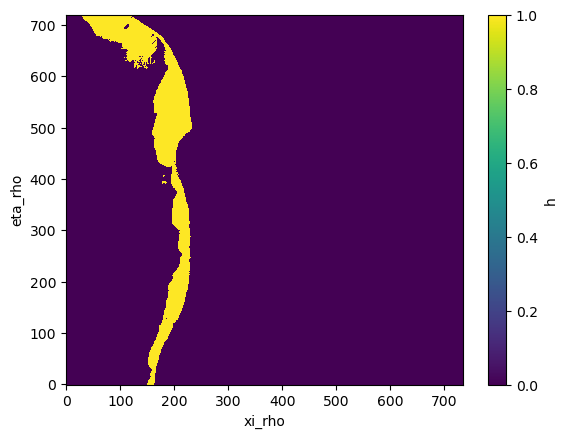

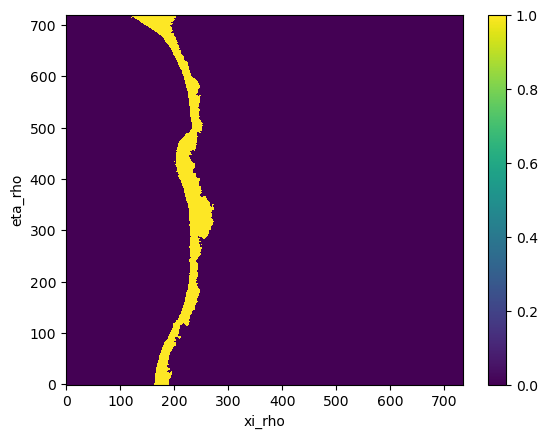

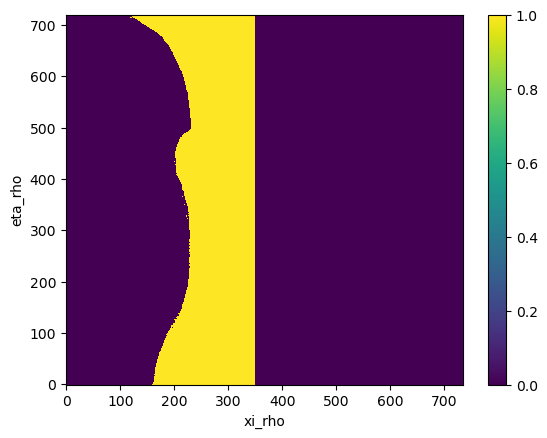

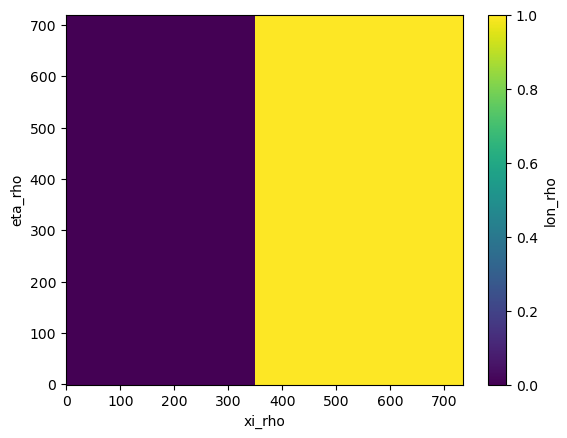

In [13]:
weights = ds.dA
weights.name = "weights"


# Shelf
mask_shelf = (ds.h<100) & (ds.h>20)

mask_shelf.plot()
plt.show()

#ds.temp.isel(s_rho=-1).where(mask_shelf).mean(dim='eta_rho').mean(dim='xi_rho').plot()
#ds.temp.isel(s_rho=-1).where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')).plot()


# Slope
mask_slope = (ds.h>100) & (ds.h<1500) & (ds.lon_rho<154.3)

mask_slope.plot()
plt.show()

# EAC
mask_eac = (ds.h>90) & (ds.lon_rho<155)

mask_eac.plot()
plt.show()

# offshore
mask_offshore = (ds.lon_rho>155)

mask_offshore.plot()
plt.show()

# make masks for obs

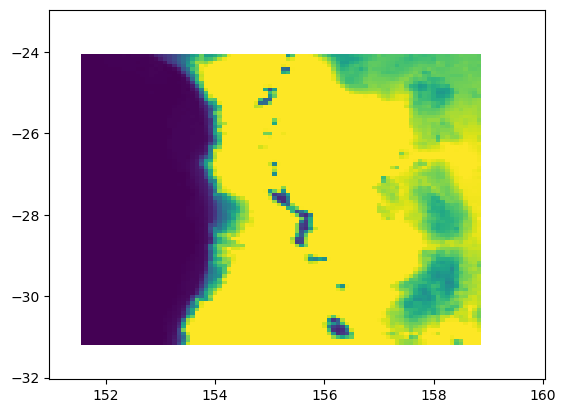

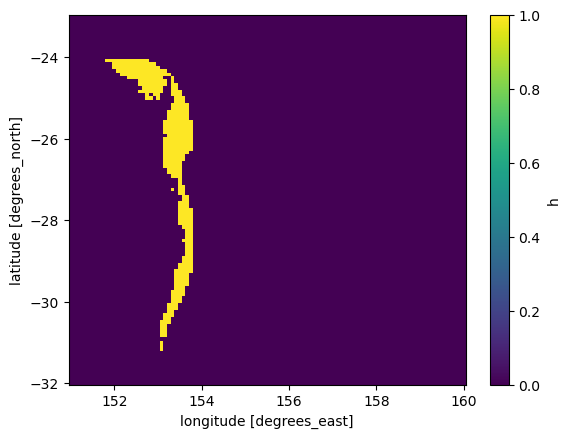

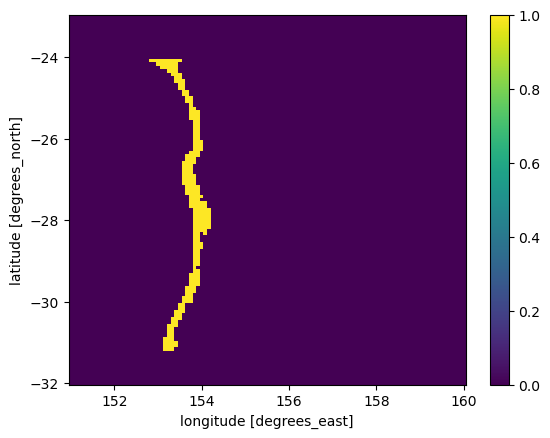

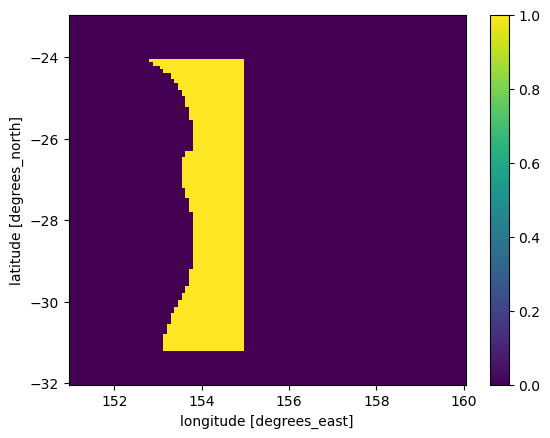

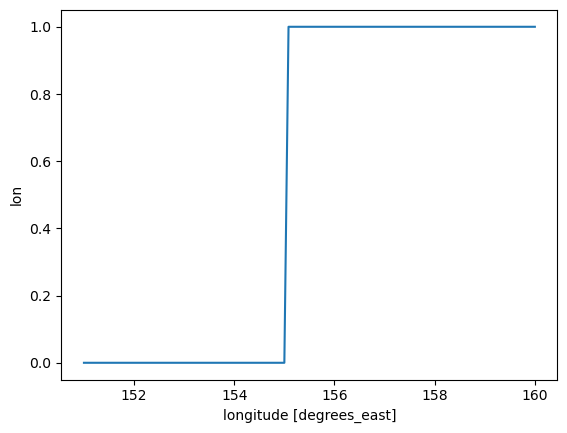

In [14]:
from scipy.interpolate import griddata


# flatten model grid
points = np.column_stack([
    ds.lon_rho.values.ravel(),
    ds.lat_rho.values.ravel()
])

values = ds.h.values.ravel()

# target grid
lon2d, lat2d = np.meshgrid(SST_ds.lon.values, SST_ds.lat.values)


# interpolate
h_interp = griddata(
    points,
    values,
    (lon2d, lat2d),
    method="linear"
)

plt.pcolormesh(SST_ds.lon,SST_ds.lat,h_interp)
plt.show()
plt.pcolormesh(ds.lon_rho,ds.lat_rho,ds.h)

SST_ds["h"] = (("lat", "lon"), h_interp)

# Shelf
mask_shelf_sst = (SST_ds.h<100) & (SST_ds.h>20)

mask_shelf_sst.plot()
plt.show()

#ds.temp.isel(s_rho=-1).where(mask_shelf).mean(dim='eta_rho').mean(dim='xi_rho').plot()
#ds.temp.isel(s_rho=-1).where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')).plot()


# Slope
mask_slope_sst = (SST_ds.h>100) & (SST_ds.h<1500) & (SST_ds.lon<154.3)

mask_slope_sst.plot()
plt.show()

# EAC
mask_eac_sst = (SST_ds.h>90) & (SST_ds.lon<155)

mask_eac_sst.plot()
plt.show()

# offshore
mask_offshore_sst = (SST_ds.lon>155)

mask_offshore_sst.plot()
plt.show()



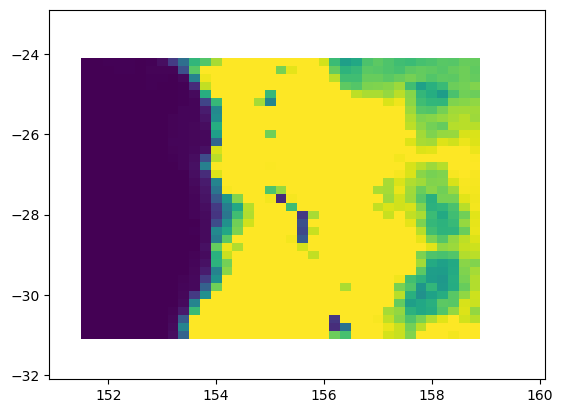

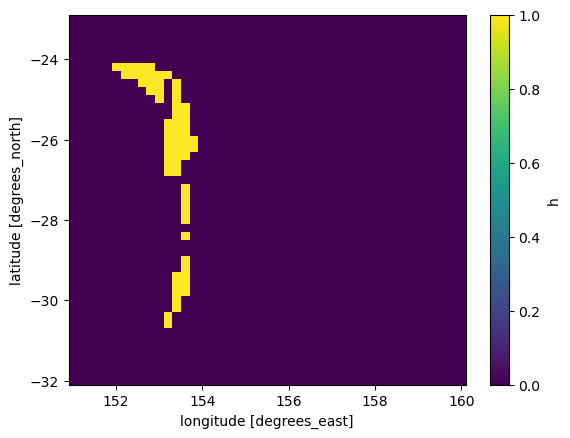

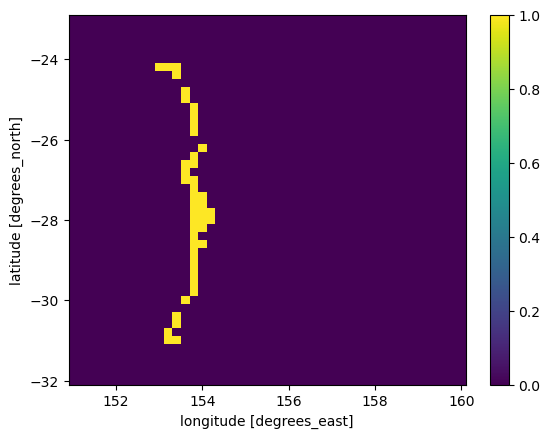

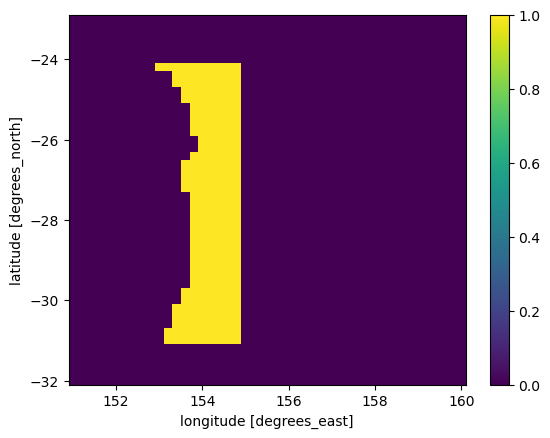

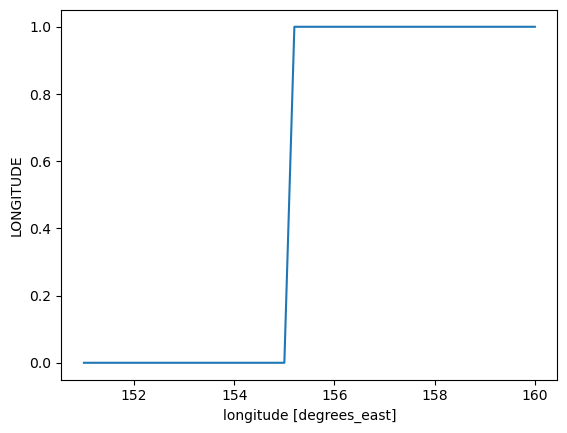

In [15]:
from scipy.interpolate import griddata


# flatten model grid
points = np.column_stack([
    ds.lon_rho.values.ravel(),
    ds.lat_rho.values.ravel()
])

values = ds.h.values.ravel()


# target grid
lon2d, lat2d = np.meshgrid(SSH_ds.LONGITUDE.values, SSH_ds.LATITUDE.values)


# interpolate
h_interp = griddata(
    points,
    values,
    (lon2d, lat2d),
    method="linear"
)

plt.pcolormesh(SSH_ds.LONGITUDE,SSH_ds.LATITUDE,h_interp)
plt.show()
plt.pcolormesh(ds.lon_rho,ds.lat_rho,ds.h)

SSH_ds["h"] = (("LATITUDE", "LONGITUDE"), h_interp)

# Shelf
mask_shelf_ssh = (SSH_ds.h<100) & (SSH_ds.h>20)

mask_shelf_ssh.plot()
plt.show()

#ds.temp.isel(s_rho=-1).where(mask_shelf).mean(dim='eta_rho').mean(dim='xi_rho').plot()
#ds.temp.isel(s_rho=-1).where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')).plot()


# Slope
mask_slope_ssh = (SSH_ds.h>100) & (SSH_ds.h<1500) & (SSH_ds.LONGITUDE<154.3)

mask_slope_ssh.plot()
plt.show()

# EAC
mask_eac_ssh = (SSH_ds.h>90) & (SSH_ds.LONGITUDE<155)

mask_eac_ssh.plot()
plt.show()

# offshore
mask_offshore_ssh = (SSH_ds.LONGITUDE>155)

mask_offshore_ssh.plot()
plt.show()



In [16]:
import warnings
def isotropic_ke_spectrum(u, v, dx, dy):
    """
    Compute isotropic KE spectrum from 2D velocity fields.
    u, v : 2D arrays
    dx, dy : grid spacing (m)
    """
    ny, nx = u.shape
    
    # ---- NaN checks ----
    nan_u = np.isnan(u).any()
    nan_v = np.isnan(v).any()

    if nan_u or nan_v:
        frac_u = np.isnan(u).mean()
        frac_v = np.isnan(v).mean()
        warnings.warn(
            f"NaNs detected in velocity field "
            f"(u: {frac_u:.2%}, v: {frac_v:.2%}). "
            "Replacing NaNs with zero before FFT.",
            RuntimeWarning
        )
        
    # Replace NaNs (land) with zero
    u = np.nan_to_num(u, nan=0.0)
    v = np.nan_to_num(v, nan=0.0)
    
    # ---- NaN checks ----
    nan_u = np.isnan(u).any()
    nan_v = np.isnan(v).any()

    if nan_u or nan_v:
        frac_u = np.isnan(u).mean()
        frac_v = np.isnan(v).mean()
        warnings.warn(
            f"NaNs STILL detected in velocity field "
            f"(u: {frac_u:.2%}, v: {frac_v:.2%}). "
            "Replacing NaNs with zero before FFT.",
            RuntimeWarning
        )

            

    # FFT
    uhat = np.fft.fft2(u)
    vhat = np.fft.fft2(v)

    # KE in spectral space
    ke_hat = 0.5 * (np.abs(uhat)**2 + np.abs(vhat)**2)

    # Wavenumbers
    kx = np.fft.fftfreq(nx, dx)
    ky = np.fft.fftfreq(ny, dy)
    kx2d, ky2d = np.meshgrid(kx, ky)

    k = np.sqrt(kx2d**2 + ky2d**2)

    # Bin isotropically
    k_bins = np.linspace(0, k.max(), min(nx, ny)//2)
    ke_spec = np.zeros(len(k_bins)-1)
    k_mid = 0.5 * (k_bins[1:] + k_bins[:-1])

    for i in range(len(k_mid)):
        mask = (k >= k_bins[i]) & (k < k_bins[i+1])
        ke_spec[i] = ke_hat[mask].sum()

    return k_mid, ke_spec


In [56]:
# Energy spectrum ROMS

#  Pick surface velocity and time-average spectra, not velocity: 

u = ds.u_eastward
v = ds.v_northward

# optionally select surface layer
u = u.isel(s_rho=-1)
v = v.isel(s_rho=-1)

# remove time mean (important)
roms_u_prime = u - u.mean("ocean_time")
roms_v_prime = v - v.mean("ocean_time")

# Grid spacing (meters):
dx_roms = float(ds.pm.mean())**-1   # ROMS convention
dy_roms = float(ds.pn.mean())**-1

In [18]:
spec_list = []

for t in range(roms_u_prime.sizes["ocean_time"]):
    k_roms, E = isotropic_ke_spectrum(
        roms_u_prime.isel(ocean_time=t).values,
        roms_v_prime.isel(ocean_time=t).values,
        dx_roms, dy_roms
    )
    spec_list.append(E)

E_mean_roms = np.mean(spec_list, axis=0)


/jobfs/162539492.gadi-pbs/ipykernel_3895402/44150996.py:17: RuntimeWarning: NaNs detected in velocity field (u: 21.49%, v: 21.49%). Replacing NaNs with zero before FFT.
  warnings.warn(


In [59]:
# Energy spectrum ROMS

#  Pick surface velocity and time-average spectra, not velocity: 

u = ds.u_eastward.sel(ocean_time=slice('2016-06-01','2016-08-31'))
v = ds.v_northward.sel(ocean_time=slice('2016-06-01','2016-08-31'))

# optionally select surface layer
u = u.isel(s_rho=-1)
v = v.isel(s_rho=-1)

# remove time mean (important)
roms_u_prime = u - u.mean("ocean_time")
roms_v_prime = v - v.mean("ocean_time")

spec_list = []

for t in range(roms_u_prime.sizes["ocean_time"]):
    k_roms_win, E = isotropic_ke_spectrum(
        roms_u_prime.isel(ocean_time=t).values,
        roms_v_prime.isel(ocean_time=t).values,
        dx_roms, dy_roms
    )
    spec_list.append(E)

E_mean_roms_win = np.mean(spec_list, axis=0)


/jobfs/162539492.gadi-pbs/ipykernel_3895402/44150996.py:17: RuntimeWarning: NaNs detected in velocity field (u: 21.49%, v: 21.49%). Replacing NaNs with zero before FFT.
  warnings.warn(


In [60]:
k_roms_win

array([9.44074570e-07, 2.83222371e-06, 4.72037285e-06, 6.60852199e-06,
       8.49667113e-06, 1.03848203e-05, 1.22729694e-05, 1.41611186e-05,
       1.60492677e-05, 1.79374168e-05, 1.98255660e-05, 2.17137151e-05,
       2.36018643e-05, 2.54900134e-05, 2.73781625e-05, 2.92663117e-05,
       3.11544608e-05, 3.30426100e-05, 3.49307591e-05, 3.68189082e-05,
       3.87070574e-05, 4.05952065e-05, 4.24833557e-05, 4.43715048e-05,
       4.62596540e-05, 4.81478031e-05, 5.00359522e-05, 5.19241014e-05,
       5.38122505e-05, 5.57003997e-05, 5.75885488e-05, 5.94766979e-05,
       6.13648471e-05, 6.32529962e-05, 6.51411454e-05, 6.70292945e-05,
       6.89174436e-05, 7.08055928e-05, 7.26937419e-05, 7.45818911e-05,
       7.64700402e-05, 7.83581894e-05, 8.02463385e-05, 8.21344876e-05,
       8.40226368e-05, 8.59107859e-05, 8.77989351e-05, 8.96870842e-05,
       9.15752333e-05, 9.34633825e-05, 9.53515316e-05, 9.72396808e-05,
       9.91278299e-05, 1.01015979e-04, 1.02904128e-04, 1.04792277e-04,
      

# calc energy spectra for satellite obs

In [19]:
# Energy spectrum OBSERVATIONS

#  Pick surface velocity and time-average spectra, not velocity: 

u = SSH_ds.UCUR.sel(TIME=slice('2012-01-01','2012-12-31'))
v = SSH_ds.VCUR.sel(TIME=slice('2012-01-01','2012-12-31'))


# remove time mean (important)
u_prime_obs = u - u.mean("TIME")
v_prime_obs = v - v.mean("TIME")




In [20]:
spec_list = []

for t in range(u_prime_obs.sizes["TIME"]):
    k_obs, E = isotropic_ke_spectrum(
        u_prime_obs.isel(TIME=t).values,
        v_prime_obs.isel(TIME=t).values,
        SSH_ds.dx.mean(dim={'LONGITUDE','LATITUDE'}).values, SSH_ds.dy.mean(dim={'LONGITUDE','LATITUDE'}).values
    )
    spec_list.append(E)

E_mean_obs = np.mean(spec_list, axis=0)


/jobfs/162539492.gadi-pbs/ipykernel_3895402/44150996.py:17: RuntimeWarning: NaNs detected in velocity field (u: 20.70%, v: 20.70%). Replacing NaNs with zero before FFT.
  warnings.warn(
/jobfs/162539492.gadi-pbs/ipykernel_3895402/44150996.py:17: RuntimeWarning: NaNs detected in velocity field (u: 20.75%, v: 20.79%). Replacing NaNs with zero before FFT.
  warnings.warn(
/jobfs/162539492.gadi-pbs/ipykernel_3895402/44150996.py:17: RuntimeWarning: NaNs detected in velocity field (u: 20.75%, v: 20.70%). Replacing NaNs with zero before FFT.
  warnings.warn(
/jobfs/162539492.gadi-pbs/ipykernel_3895402/44150996.py:17: RuntimeWarning: NaNs detected in velocity field (u: 20.75%, v: 20.70%). Replacing NaNs with zero before FFT.
  warnings.warn(
/jobfs/162539492.gadi-pbs/ipykernel_3895402/44150996.py:17: RuntimeWarning: NaNs detected in velocity field (u: 20.75%, v: 20.70%). Replacing NaNs with zero before FFT.
  warnings.warn(
/jobfs/162539492.gadi-pbs/ipykernel_3895402/44150996.py:17: RuntimeWar

# now load bran

In [21]:
# load other model data

# /g/data/gb6/BRAN/BRAN2023/daily/ocean_u_2012_*.nc



# Need to chunk
ds_u = xr.open_mfdataset('/g/data/gb6/BRAN/BRAN2023/daily/ocean_u_2012_*.nc').sel(xu_ocean=slice(145,162)
                                                                                ,yu_ocean=slice(-32,-22)
                                                                                )
ds_v = xr.open_mfdataset('/g/data/gb6/BRAN/BRAN2023/daily/ocean_v_2012_*.nc').sel(xu_ocean=slice(145,162)
                                                                                ,yu_ocean=slice(-32,-22)
                                                                                )
# ds_w = xr.open_mfdataset('/g/data/gb6/BRAN/BRAN2023/daily/ocean_w_2012_*.nc').sel(xt_ocean=slice(145,162)
#                                                                                 ,yt_ocean=slice(-32,-22)
#                                                                                 )

# ds_grid_bran = xr.open_dataset('/g/data/gb6/BRAN/BRAN2023/static/grid_spec.nc')


ds_u.load()
print('loaded u')
ds_v.load()
print('loaded v')
# ds_w.load()
# print('loaded w')




loaded u
loaded v


In [22]:
ds_u

<xarray.Dataset>
Dimensions:         (xu_ocean: 171, yu_ocean: 101, st_ocean: 51, Time: 366,
                     nv: 2, st_edges_ocean: 52)
Coordinates:
  * xu_ocean        (xu_ocean) float64 145.0 145.1 145.2 ... 161.8 161.9 162.0
  * yu_ocean        (yu_ocean) float64 -32.0 -31.9 -31.8 ... -22.2 -22.1 -22.0
  * st_ocean        (st_ocean) float64 2.5 7.5 12.5 ... 3.603e+03 4.509e+03
  * Time            (Time) datetime64[ns] 2012-01-01T12:00:00 ... 2012-12-31T...
  * nv              (nv) float64 1.0 2.0
  * st_edges_ocean  (st_edges_ocean) float64 0.0 5.0 10.0 ... 4.056e+03 5e+03
Data variables:
    average_T1      (Time) datetime64[ns] 2012-01-01 2012-01-02 ... 2012-12-31
    average_T2      (Time) datetime64[ns] 2012-01-02 2012-01-03 ... 2013-01-01
    average_DT      (Time) timedelta64[ns] 1 days 1 days ... 1 days 1 days
    Time_bnds       (Time, nv) timedelta64[ns] 12053 days ... 12419 days
    u               (Time, st_ocean, yu_ocean, xu_ocean) float32 nan nan ... nan
Attributes:
    filename:                   TMP/ocean_ofam_2012_01_01.nc.0000
    NumFilesInSet:              20
    title:                      BRAN2023
    grid_type:                  regular
    NCO:                        netCDF Operators version 5.0.5 (Homepage = ht...
    history:                    Mon Jul 29 12:20:35 2024: ncks -A -v Time_bnd...
    history_of_appended_files:  Mon Jul 29 12:20:35 2024: Appended file ocean...
    acknowledgement:            BRAN output is made freely available by CSIRO...
    catalogue_doi_url:           https://dx.doi.org/10.25914/2wxj-vt48

In [23]:
# Energy spectrum BRAN

u = ds_u.u.sel(Time=slice('2012-01-01','2012-12-31')).isel(st_ocean=0)
v = ds_v.v.sel(Time=slice('2012-01-01','2012-12-31')).isel(st_ocean=0)


# remove time mean (important)
u_prime_bran = u - u.mean("Time")
v_prime_bran = v - v.mean("Time")


lon = ds_u.xu_ocean
lat = ds_u.yu_ocean

# convert to radians
lon_rad = np.deg2rad(lon)
lat_rad = np.deg2rad(lat)

# grid spacing
dlon = lon_rad.diff('xu_ocean')
dlat = lat_rad.diff('yu_ocean')

# dx, dy on staggered dimensions
R = 6371e3  # Earth radius [m]
dx = R * np.cos(lat_rad) * dlon
dy = R * dlat

#correct for better broadcasting
dx_bran = dx.mean(dim={'yu_ocean','xu_ocean'})
dy_bran = dy.mean(dim={'yu_ocean'})


In [24]:
spec_list = []

for t in range(u_prime_bran.sizes["Time"]):
    k_bran, E = isotropic_ke_spectrum(
        u_prime_bran.isel(Time=t).values,
        v_prime_bran.isel(Time=t).values,
        dx_bran.values, dy_bran.values
    )
    spec_list.append(E)

E_mean_bran = np.mean(spec_list, axis=0)


/jobfs/162539492.gadi-pbs/ipykernel_3895402/44150996.py:17: RuntimeWarning: NaNs detected in velocity field (u: 45.46%, v: 45.46%). Replacing NaNs with zero before FFT.
  warnings.warn(


# now calculate energy spectra

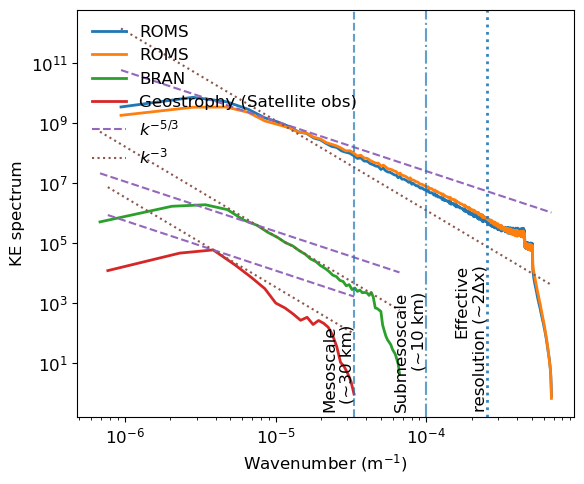

In [61]:
L_sub = 10e3       # 10 km
L_meso = 30e3      # 30 km
L_eff_roms = 4 * dx_roms     # effective resolution

k_grid = 1 / dx
k_eff_roms  = 1 / L_eff_roms
k_sub  = 1 / L_sub
k_meso = 1 / L_meso

plt.figure(figsize=(6,5))
plt.loglog(k_roms, E_mean_roms, label="ROMS", lw=2)
plt.loglog(k_roms_win, E_mean_roms_win, label="ROMS", lw=2)

plt.loglog(k_bran, E_mean_bran, label="BRAN", lw=2)
plt.loglog(k_obs, E_mean_obs, label="Geostrophy (Satellite obs)", lw=2)

# reference slopes for ROMS
plt.loglog(
    k_roms, k_roms**(-5/3) * E_mean_roms[5] / k_roms[5]**(-5/3),
    "--", label=r"$k^{-5/3}$",color='C4'
)
plt.loglog(
    k_roms, k_roms**(-3) * E_mean_roms[5] / k_roms[5]**(-3),
    ":", label=r"$k^{-3}$",color='C5'
)

# reference slopes for BRAN
plt.loglog(
    k_bran, k_bran**(-5/3) * E_mean_bran[5] / k_bran[5]**(-5/3),
    "--",color='C4'
)
plt.loglog(
    k_bran, k_bran**(-3) * E_mean_bran[5] / k_bran[5]**(-3),
    ":",color='C5'
)

# reference slopes for obs
plt.loglog(
    k_obs, k_obs**(-5/3) * E_mean_obs[2] / k_obs[2]**(-5/3),
    "--", color='C4'
)
plt.loglog(
    k_obs, k_obs**(-3) * E_mean_obs[2] / k_obs[2]**(-3),
    ":", color='C5'
)


# vertical scale markers
plt.axvline(k_meso, ls="--", lw=1.5, alpha=0.7)
plt.text(k_meso, plt.ylim()[0]*1.5, "Mesoscale\n(~30 km)",
         rotation=90, va="bottom", ha="right")

plt.axvline(k_sub, ls="-.", lw=1.5, alpha=0.7)
plt.text(k_sub, plt.ylim()[0]*1.5, "Submesoscale\n(~10 km)",
         rotation=90, va="bottom", ha="right")

plt.axvline(k_eff_roms, ls=":", lw=2, alpha=0.9)
plt.text(k_eff_roms, plt.ylim()[0]*1.5, "Effective\nresolution (~2Δx)",
         rotation=90, va="bottom", ha="right")

plt.xlabel("Wavenumber (m$^{-1}$)")
plt.ylabel("KE spectrum")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [26]:
k_eff_roms

0.0002539592746964285

In [27]:
# compensated spectrum and cumulative KE

# E_comp_53 = k**(5/3) * E_mean
# E_comp_3  = k**3 * E_mean


E_cumulative_roms = np.cumsum(E_mean_roms * np.gradient(k_roms))
E_cumulative_roms /= E_cumulative_roms[-1]  # normalise


E_cumulative_bran = np.cumsum(E_mean_bran * np.gradient(k_bran))
E_cumulative_bran /= E_cumulative_bran[-1]  # normalise


E_cumulative_obs = np.cumsum(E_mean_obs * np.gradient(k_obs))
E_cumulative_obs /= E_cumulative_obs[-1]  # normalise



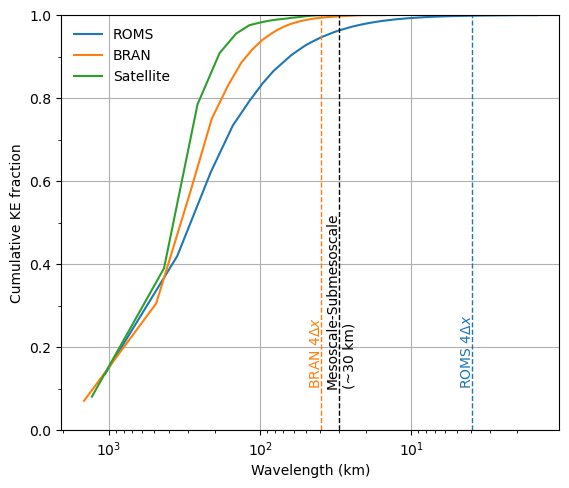

In [28]:
from matplotlib.ticker import MultipleLocator

L_mesoscale = 30.0      # mesoscale / submesoscale boundary
L_submeso = 10.0        # upper submesoscale


L_eff_roms = 4 * dx_roms/1000
L_eff_bran = 4 * dx_bran/1000


# --- Figure + GridSpec ---
fig = plt.figure(figsize=(6, 5))
gs = gridspec.GridSpec(nrows=1, ncols=1,left=0.12, right=0.95,bottom=0.12, top=0.95)

ax = fig.add_subplot(gs[0])

# --- Cumulative KE curves ---
ax.semilogx(1 / k_roms / 1000, E_cumulative_roms, label='ROMS')
ax.semilogx(1 / k_bran / 1000, E_cumulative_bran, label='BRAN')
ax.semilogx(1 / k_obs  / 1000, E_cumulative_obs,  label='Satellite')

# --- Physical scale boundaries ---
ax.axvline(L_mesoscale, color='k', linestyle='--', linewidth=1)
# ax.axvline(L_submeso,   color='k', linestyle=':',  linewidth=1)

# --- Model effective resolutions ---
ax.axvline(L_eff_roms, color='tab:blue',   linestyle='--', linewidth=1)
ax.axvline(L_eff_bran, color='tab:orange', linestyle='--', linewidth=1)

# --- Labels ---
ax.text(L_mesoscale * 1.22, 0.1,'Mesoscale-Submesoscale\n(~30 km)',rotation=90, va='bottom', ha='left')

# ax.text(L_submeso * 1.22, 0.1,'Upper submesoscale\n(~10 km)',rotation=90, va='bottom', ha='left')

ax.text(L_eff_roms * 1.2, 0.1,r'ROMS $4\Delta x$',rotation=90, va='bottom', ha='left',color='tab:blue')

ax.text(L_eff_bran * 1.2, 0.1,r'BRAN $4\Delta x$',rotation=90, va='bottom', ha='left',color='tab:orange')

# --- Axes formatting ---
ax.set_xlabel("Wavelength (km)")
ax.set_ylabel("Cumulative KE fraction")
ax.set_ylim(0, 1)
ax.invert_xaxis()
ax.grid()
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
ax.legend(frameon=False)

plt.show()



# combine into single plot

Text(0.011, 0.97, 'b')

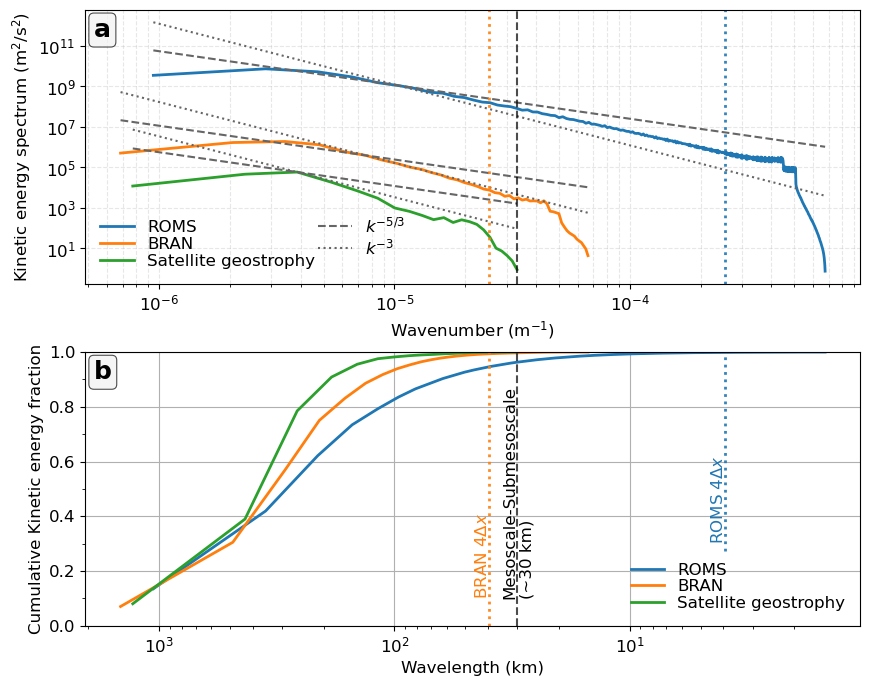

In [48]:
from matplotlib.ticker import MultipleLocator

plt.rcParams['font.size'] = '12'
plt.rcParams['xtick.labelsize']='12'
plt.rcParams['ytick.labelsize']='12'

L_mesoscale = 30000.0      # mesoscale / submesoscale boundary
L_eff_roms = 4 * dx_roms
L_eff_bran = 4 * dx_bran


k_eff_roms  = 1 / L_eff_roms
k_eff_bran  = 1 / L_eff_bran
k_meso = 1 / L_mesoscale


fig = plt.figure(figsize=(10,8))
gs = gridspec.GridSpec(2, 1, hspace=0.25, wspace=0.2)

# --- Left plot: KE spectrum ---
ax1 = fig.add_subplot(gs[0,0])

# KE spectra
ax1.loglog(k_roms, E_mean_roms, label="ROMS", lw=2)
ax1.loglog(k_bran, E_mean_bran, label="BRAN", lw=2)
ax1.loglog(k_obs, E_mean_obs, label="Satellite geostrophy", lw=2)

# Reference slopes (standard colours)
ax1.loglog(k_roms, k_roms**(-5/3) * E_mean_roms[5]/k_roms[5]**(-5/3), "--", label=r"$k^{-5/3}$", color="0.4")
ax1.loglog(k_roms, k_roms**(-3)   * E_mean_roms[5]/k_roms[5]**(-3), ":", label=r"$k^{-3}$", color="0.4")
ax1.loglog(k_bran, k_bran**(-5/3)*E_mean_bran[5]/k_bran[5]**(-5/3), "--", color="0.4")
ax1.loglog(k_bran, k_bran**(-3)*E_mean_bran[5]/k_bran[5]**(-3), ":", color="0.4")
ax1.loglog(k_obs, k_obs**(-5/3)*E_mean_obs[2]/k_obs[2]**(-5/3), "--", color="0.4")
ax1.loglog(k_obs, k_obs**(-3)*E_mean_obs[2]/k_obs[2]**(-3), ":", color="0.4")

# --- Vertical lines with standard colours ---
vline_colours = {"Mesoscale": "k", "Submesoscale": "k", "ROMS 4dx": "tab:blue", "BRAN 4dx": "tab:orange"}

ax1.axvline(k_meso, ls="--", lw=1.5, color=vline_colours["Mesoscale"], alpha=0.7)
# ax1.axvline(k_sub, ls="-.", lw=1.5, color=vline_colours["Submesoscale"], alpha=0.7)
ax1.axvline(k_eff_roms, ls=":", lw=2, color=vline_colours["ROMS 4dx"], alpha=0.9)
ax1.axvline(k_eff_bran, ls=":", lw=2, color=vline_colours["BRAN 4dx"], alpha=0.9)

# --- Labels for vertical lines ---
# ax1.text(k_meso, ax1.get_ylim()[0]*1.5, "Mesoscale\n(~30 km)", rotation=90, va="bottom", ha="right", color=vline_colours["Mesoscale"])
# ax1.text(k_sub, ax1.get_ylim()[0]*1.5, "Submesoscale\n(~10 km)", rotation=90, va="bottom", ha="right", color=vline_colours["Submesoscale"])
# ax1.text(k_eff_roms, ax1.get_ylim()[0]*1.5, "ROMS\n4Δx", rotation=90, va="bottom", ha="right", color=vline_colours["ROMS 4dx"])
# ax1.text(k_eff_bran, ax1.get_ylim()[0]*1.5, "BRAN\n4Δx", rotation=90, va="bottom", ha="right", color=vline_colours["BRAN 4dx"])


# --- Grid and formatting ---
ax1.grid(True, which="both", axis="both", linestyle="--", alpha=0.3)
ax1.set_xlabel(r"Wavenumber (m$^{-1}$)")
ax1.set_ylabel("Kinetic energy spectrum (m$^2$/s$^2$)")
ax1.legend(frameon=False,ncol=2,loc='lower left',labelspacing=0.1,columnspacing=0.2)
# ax1.text(0.03, 0.97, 'a', transform=ax1.transAxes,fontsize=18, fontweight='bold', va='top')

ax1.text(0.011, 0.97, 'a', transform=ax1.transAxes,fontsize=18, fontweight='bold', va='top',bbox=dict(
        boxstyle='round,pad=0.2',
        facecolor='0.95',
        edgecolor='black',
        linewidth=0.8,
        alpha=0.7
    ))


# --- Right plot: cumulative KE ---
ax2 = fig.add_subplot(gs[1,0])

ax2.semilogx(1/k_roms/1000, E_cumulative_roms, label="ROMS", lw=2)
ax2.semilogx(1/k_bran/1000, E_cumulative_bran, label="BRAN", lw=2)
ax2.semilogx(1/k_obs/1000, E_cumulative_obs, label="Satellite geostrophy", lw=2)

ax2.axvline(L_mesoscale/1000, color=vline_colours["Mesoscale"], ls="--", lw=1.5, alpha=0.7)
ax2.axvline(L_eff_roms/1000, ymin=0.275, color=vline_colours["ROMS 4dx"], ls=":", lw=2, alpha=0.9)
ax2.axvline(L_eff_bran/1000, color=vline_colours["BRAN 4dx"], ls=":", lw=2, alpha=0.9)

ax2.text(L_mesoscale/1000 * 1.16, 0.1,'Mesoscale-Submesoscale\n(~30 km)',rotation=90, va='bottom', ha='left')
ax2.text(L_eff_roms/1000 * 1.16, 0.3,r'ROMS $4\Delta x$',rotation=90, va='bottom', ha='left',color='tab:blue')
ax2.text(L_eff_bran/1000 * 1.16, 0.1,r'BRAN $4\Delta x$',rotation=90, va='bottom', ha='left',color='tab:orange')

ax2.set_xlabel("Wavelength (km)")
ax2.set_ylabel("Cumulative Kinetic energy fraction")
ax2.invert_xaxis()
ax2.set_ylim(0,1)
ax2.legend(frameon=False,loc='lower right',labelspacing=0.1)
ax2.grid()
ax2.yaxis.set_minor_locator(MultipleLocator(0.1))
# ax2.text(0.03, 0.97, 'b', transform=ax2.transAxes,fontsize=18, fontweight='bold', va='top')

ax2.text(0.011, 0.97, 'b', transform=ax2.transAxes,fontsize=18, fontweight='bold', va='top',bbox=dict(
        boxstyle='round,pad=0.2',
        facecolor='0.95',
        edgecolor='black',
        linewidth=0.8,
        alpha=0.7
    ))


In [30]:
print(E_cumulative_roms[np.argmin(np.abs(1/k_roms/1000 - 30))])
print(E_cumulative_bran[np.argmin(np.abs(1/k_bran/1000 - 30))])
print(E_cumulative_obs[np.argmin(np.abs(1/k_obs/1000 - 30))])



0.9627053853415398
0.9971734678776382
1.0


In [31]:
L_mesoscale/1000 * 1.22

36.6

In [32]:
k_eff

NameError: name 'k_eff' is not defined

In [ ]:
plt.figure(figsize=(6,5))
plt.semilogx(k, E_comp_53,'C0')
# plt.semilogx(k, E_comp_3,'C1')

plt.axhline(0, color="k", lw=0.5)
plt.xlabel("Wavenumber (m$^{-1}$)")
plt.ylabel(r"$k^{5/3} E(k)$")
plt.tight_layout()
plt.show()


In [ ]:
dx

In [ ]:
L_sub = 10e3       # 10 km
L_meso = 50e3      # 50 km
L_eff = 2 * roms_dx     # effective resolution

k_grid = 1 / roms_dx
k_eff  = 1 / L_eff
k_sub  = 1 / L_sub
k_meso = 1 / L_meso

plt.figure(figsize=(6,5))
plt.loglog(k, E_mean, label="ROMS", lw=2)


# reference slopes
plt.loglog(
    k, k**(-5/3) * E_mean[5] / k[5]**(-5/3),
    "--", label=r"$k^{-5/3}$"
)
plt.loglog(
    k, k**(-3) * E_mean[5] / k[5]**(-3),
    ":", label=r"$k^{-3}$"
)

# vertical scale markers
plt.axvline(k_meso, ls="--", lw=1.5, alpha=0.7)
plt.text(k_meso, plt.ylim()[0]*1.5, "Mesoscale\n(~50 km)",
         rotation=90, va="bottom", ha="right")

plt.axvline(k_sub, ls="-.", lw=1.5, alpha=0.7)
plt.text(k_sub, plt.ylim()[0]*1.5, "Submesoscale\n(~10 km)",
         rotation=90, va="bottom", ha="right")

plt.axvline(k_eff, ls=":", lw=2, alpha=0.9)
plt.text(k_eff, plt.ylim()[0]*1.5, "Effective\nresolution (~2Δx)",
         rotation=90, va="bottom", ha="right")

plt.xlabel("Wavenumber (m$^{-1}$)")
plt.ylabel("KE spectrum")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
k.shape

In [ ]:
STOP

In [ ]:
%%time

gs = gridspec.GridSpec(nrows=3,ncols=4,wspace=0.05, hspace=0.25)
plt.cla()
plt.clf()
fig = plt.figure(figsize=[16,8])#what is this?
ax = None
plt.rcParams['font.size'] = '14'
plt.rcParams['xtick.labelsize']='14'
plt.rcParams['ytick.labelsize']='14'

# Shelf
ax = fig.add_subplot(gs[0,0])

ax.plot(times,ds.temp.isel(s_rho=-1).where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SST_ds.time.sel(time=slice('2012-01-01','2013-01-01')),SST_ds.sst.sel(time=slice('2012-01-01','2013-01-01')).where(mask_shelf_sst).mean(('lon','lat')))


ax.set_ylim(19,29)
# ax.set(ylabel = "SST ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'Shelf', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'a', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.text(0.03, 0.16, 'SST', transform=ax.transAxes,fontsize=16, fontweight='bold', va='top')

##############################
# Slope
ax = fig.add_subplot(gs[0,1])
ax.plot(times,ds.temp.isel(s_rho=-1).where(mask_slope).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SST_ds.time.sel(time=slice('2012-01-01','2013-01-01')),SST_ds.sst.sel(time=slice('2012-01-01','2013-01-01')).where(mask_slope_sst).mean(('lon','lat')))

ax.set_ylim(19,29)
# ax.set(ylabel = "SST ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'Slope', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'b', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')

##############################
# EAC
ax = fig.add_subplot(gs[0,2])
ax.plot(times,ds.temp.isel(s_rho=-1).where(mask_eac).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SST_ds.time.sel(time=slice('2012-01-01','2013-01-01')),SST_ds.sst.sel(time=slice('2012-01-01','2013-01-01')).where(mask_eac_sst).mean(('lon','lat')))


ax.set_ylim(19,29)
# ax.set(ylabel = "SST ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'EAC-deep', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'c', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')

#############################
# Offshore
ax = fig.add_subplot(gs[0,3])
ax.plot(times,ds.temp.isel(s_rho=-1).where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')))

ax.plot(SST_ds.time.sel(time=slice('2012-01-01','2013-01-01')),SST_ds.sst.sel(time=slice('2012-01-01','2013-01-01')).where(mask_offshore_sst).mean(('lon','lat')))

ax.set_ylim(19,29)
# ax.set(ylabel = "SST ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'Offshore', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'd', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_xticklabels('')
ax.set_yticklabels('')


In [ ]:
# now do SSH
SSH_ds

In [ ]:
%%time

gs = gridspec.GridSpec(nrows=3,ncols=4,wspace=0.05, hspace=0.25)
plt.cla()
plt.clf()
fig = plt.figure(figsize=[16,8])#what is this?
ax = None
plt.rcParams['font.size'] = '14'
plt.rcParams['xtick.labelsize']='14'
plt.rcParams['ytick.labelsize']='14'

# Shelf
ax = fig.add_subplot(gs[1,0])

ax.plot(times,ds.zeta.where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2013-01-01')),SSH_ds.GSL.sel(TIME=slice('2012-01-01','2013-01-01')).where(mask_shelf_ssh).mean(('LONGITUDE','LATITUDE')))


ax.set_ylim(.15,.75)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'Shelf', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'e', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.text(0.03, 0.16, 'SSH', transform=ax.transAxes,fontsize=16, fontweight='bold', va='top')

##############################
# Slope
ax = fig.add_subplot(gs[1,1])
ax.plot(times,ds.zeta.where(mask_slope).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2013-01-01')),SSH_ds.GSL.sel(TIME=slice('2012-01-01','2013-01-01')).where(mask_slope_ssh).mean(('LONGITUDE','LATITUDE')))

ax.set_ylim(.15,.75)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'Slope', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'f', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')

##############################
# EAC
ax = fig.add_subplot(gs[1,2])
ax.plot(times,ds.zeta.where(mask_eac).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2013-01-01')),SSH_ds.GSL.sel(TIME=slice('2012-01-01','2013-01-01')).where(mask_eac_ssh).mean(('LONGITUDE','LATITUDE')))


ax.set_ylim(.15,.75)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'EAC-deep', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'g', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')

#############################
# Offshore
ax = fig.add_subplot(gs[1,3])
ax.plot(times,ds.zeta.where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')))

ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2013-01-01')),SSH_ds.GSL.sel(TIME=slice('2012-01-01','2013-01-01')).where(mask_offshore_ssh).mean(('LONGITUDE','LATITUDE')))

ax.set_ylim(.15,.75)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'Offshore', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'h', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_xticklabels('')
ax.set_yticklabels('')


# now kinetic energy

In [ ]:
(0.5*(ds.u_eastward.isel(s_rho=-1)**2 + ds.v_northward.isel(s_rho=-1)**2)).weighted(weights).mean(('eta_rho','xi_rho')).plot()

In [ ]:
# calculate ke's

ke = (0.5*(ds.u_eastward.isel(s_rho=-1)**2 + ds.v_northward.isel(s_rho=-1)**2))

ke_ssh = (0.5*(SSH_ds.UCUR.sel(TIME=slice('2011-12-01','2013-01-31'))**2 + SSH_ds.VCUR.sel(TIME=slice('2011-12-01','2013-01-31'))**2))

ke_ssh

In [ ]:
SSH_ds.TIME

In [ ]:
%%time

gs = gridspec.GridSpec(nrows=3,ncols=4,wspace=0.05, hspace=0.25)
plt.cla()
plt.clf()
fig = plt.figure(figsize=[16,8])#what is this?
ax = None
plt.rcParams['font.size'] = '14'
plt.rcParams['xtick.labelsize']='14'
plt.rcParams['ytick.labelsize']='14'

# Shelf
ax = fig.add_subplot(gs[2,0])

ax.plot(times,ke.where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_shelf_ssh).mean(('LONGITUDE','LATITUDE')))


ax.set_ylim(0,0.5)
ax.set(ylabel = r"$\langle \mathrm{KE} \rangle$ (m$^2$/s$^2$)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2012-12-31"))
ax.text(0.96, 0.97, 'Shelf', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'i', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.text(0.03, 0.16, r'$\langle \mathrm{KE} \rangle$', transform=ax.transAxes,fontsize=16, fontweight='bold', va='top')
ax.tick_params(axis='x', labelrotation=60)
##############################
# Slope
ax = fig.add_subplot(gs[2,1])
ax.plot(times,ke.where(mask_slope).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_slope_ssh).mean(('LONGITUDE','LATITUDE')))

ax.set_ylim(0,0.5)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2012-12-31"))
ax.text(0.96, 0.97, 'Slope', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'j', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')
ax.tick_params(axis='x', labelrotation=60)
##############################
# EAC
ax = fig.add_subplot(gs[2,2])
ax.plot(times,ke.where(mask_eac).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_eac_ssh).mean(('LONGITUDE','LATITUDE')))


ax.set_ylim(0,0.5)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2012-12-31"))
ax.text(0.96, 0.97, 'EAC-deep', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'k', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')
ax.tick_params(axis='x', labelrotation=60)
#############################
# Offshore
ax = fig.add_subplot(gs[2,3])
ax.plot(times,ke.where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')))

ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_offshore_ssh).mean(('LONGITUDE','LATITUDE')))

ax.set_ylim(0,0.5)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2012-12-31"))
ax.text(0.96, 0.97, 'Offshore', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'l', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')
ax.tick_params(axis='x', labelrotation=60)

In [ ]:
import numpy as np

def datetime_to_float_ns(t):
    return t.astype("datetime64[ns]").astype("int64").astype(float)


def rmse_on_common_time(
    ts1, t1,
    ts2, t2,
    target_time,
    return_interpolated=False
):
    """
    Interpolate two time series onto a common time vector and compute RMSE.

    Parameters
    ----------
    return_interpolated : bool
        If True, also return interpolated ts1, ts2, and time vector.
    """

    t1n = datetime_to_float_ns(t1)
    t2n = datetime_to_float_ns(t2)
    ttn = datetime_to_float_ns(target_time)

    # Overlapping window
    tmin = max(t1n.min(), t2n.min())
    tmax = min(t1n.max(), t2n.max())

    overlap = (ttn >= tmin) & (ttn <= tmax)
    if not np.any(overlap):
        raise ValueError("No overlapping time period between datasets.")

    ttn = ttn[overlap]

    # Interpolate
    ts1i = np.interp(ttn, t1n, ts1)
    ts2i = np.interp(ttn, t2n, ts2)

    rmse = np.sqrt(np.mean((ts1i - ts2i)**2))

    if return_interpolated:
        # Convert numeric time back to datetime64[ns]
        t_interp = ttn.astype("int64").astype("datetime64[ns]")
        return rmse, ts1i, ts2i, t_interp

    return rmse


In [ ]:
target_time = np.arange(
    np.datetime64("2012-01-01"),
    np.datetime64("2013-01-01"),
    np.timedelta64(1, "D")
).astype("datetime64[ns]")

rmse_shelf_ke = rmse_on_common_time(
    ke.where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')), times,
    ke_ssh.sel(TIME=slice('2012-01-01','2013-01-31')).where(mask_shelf_ssh).mean(('LONGITUDE','LATITUDE')),   SSH_ds.TIME.sel(TIME=slice('2012-01-01','2013-01-31')),
    target_time
)

rmse_slope_ke = rmse_on_common_time(
    ke.where(mask_slope).weighted(weights).mean(('eta_rho','xi_rho')), times,
    ke_ssh.sel(TIME=slice('2012-01-01','2013-01-31')).where(mask_slope_ssh).mean(('LONGITUDE','LATITUDE')),   SSH_ds.TIME.sel(TIME=slice('2012-01-01','2013-01-31')),
    target_time
)


rmse_eac_ke = rmse_on_common_time(
    ke.where(mask_eac).weighted(weights).mean(('eta_rho','xi_rho')), times,
    ke_ssh.sel(TIME=slice('2012-01-01','2013-01-31')).where(mask_eac_ssh).mean(('LONGITUDE','LATITUDE')),   SSH_ds.TIME.sel(TIME=slice('2012-01-01','2013-01-31')),
    target_time
)

rmse_offshore_ke = rmse_on_common_time(
    ke.where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')), times,
    ke_ssh.sel(TIME=slice('2012-01-01','2013-01-31')).where(mask_offshore_ssh).mean(('LONGITUDE','LATITUDE')),   SSH_ds.TIME.sel(TIME=slice('2012-01-01','2013-01-31')),
    target_time
)


print(rmse_shelf_ke)
print(rmse_slope_ke)
print(rmse_eac_ke)
print(rmse_offshore_ke)


In [ ]:
def annotate_rmse(
    ax,
    t1, ts1,
    t2, ts2,
    target_time,
    label=r'$\langle \mathrm{KE} \rangle$',
    xy=(0.03, 0.1),
    fontsize=12,
    return_interpolated=False
):
    out = rmse_on_common_time(
        ts1, t1,
        ts2, t2,
        target_time,
        return_interpolated=return_interpolated
    )

    if return_interpolated:
        rmse, ts1i, ts2i, t_interp = out
    else:
        rmse = out

    ax.text(
        xy[0], xy[1],
        rf'{label} = {rmse:.3f}',
        transform=ax.transAxes,
        fontsize=fontsize,
        fontweight='bold',
        va='top'
    )

    if return_interpolated:
        return rmse, ts1i, ts2i, t_interp

    return rmse


In [ ]:
%%time

gs = gridspec.GridSpec(nrows=3,ncols=4,wspace=0.05, hspace=0.25)
plt.cla()
plt.clf()
fig = plt.figure(figsize=[16,8])#what is this?
ax = None
plt.rcParams['font.size'] = '14'
plt.rcParams['xtick.labelsize']='14'
plt.rcParams['ytick.labelsize']='14'

# Shelf
ax = fig.add_subplot(gs[2,0])

ax.plot(times,ke.where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_shelf_ssh).mean(('LONGITUDE','LATITUDE')))


ax.set_ylim(0,0.5)
ax.set(ylabel = r"$\langle \mathrm{KE} \rangle$ (m$^2$/s$^2$)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2012-12-31"))
ax.text(0.96, 0.97, 'Shelf', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'i', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
# ax.text(0.03, 0.16, r'$\langle \mathrm{KE} \rangle$', transform=ax.transAxes,fontsize=16, fontweight='bold', va='top')
ax.tick_params(axis='x', labelrotation=60)
rmse = annotate_rmse(ax,times,ke.where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')),
                     SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_shelf_ssh).mean(('LONGITUDE','LATITUDE')),
                     target_time,label=r'RMSE')
##############################
# Slope
ax = fig.add_subplot(gs[2,1])
ax.plot(times,ke.where(mask_slope).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_slope_ssh).mean(('LONGITUDE','LATITUDE')))

ax.set_ylim(0,0.5)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2012-12-31"))
ax.text(0.96, 0.97, 'Slope', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'j', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')
ax.tick_params(axis='x', labelrotation=60)
rmse = annotate_rmse(ax,times,ke.where(mask_slope).weighted(weights).mean(('eta_rho','xi_rho')),
                     SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_slope_ssh).mean(('LONGITUDE','LATITUDE')),
                     target_time,label=r'RMSE')
##############################
# EAC
ax = fig.add_subplot(gs[2,2])
ax.plot(times,ke.where(mask_eac).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_eac_ssh).mean(('LONGITUDE','LATITUDE')))


ax.set_ylim(0,0.5)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2012-12-31"))
ax.text(0.96, 0.97, 'EAC-deep', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'k', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')
ax.tick_params(axis='x', labelrotation=60)
rmse = annotate_rmse(ax,times,ke.where(mask_eac).weighted(weights).mean(('eta_rho','xi_rho')),
                     SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_eac_ssh).mean(('LONGITUDE','LATITUDE')),
                     target_time,label=r'RMSE')
#############################
# Offshore
ax = fig.add_subplot(gs[2,3])
ax.plot(times,ke.where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')))

ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_offshore_ssh).mean(('LONGITUDE','LATITUDE')))

ax.set_ylim(0,0.5)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2012-12-31"))
ax.text(0.96, 0.97, 'Offshore', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'l', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')
ax.tick_params(axis='x', labelrotation=60)
rmse = annotate_rmse(ax,times,ke.where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')),
                     SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_offshore_ssh).mean(('LONGITUDE','LATITUDE')),
                     target_time,label=r'RMSE')

In [ ]:
rmse, ts1i, ts2i, t_interp = rmse_on_common_time(
    ke.where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')),times,
                     ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_offshore_ssh).mean(('LONGITUDE','LATITUDE')),SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),
    target_time,
    return_interpolated=True
)

plt.plot(t_interp, ts1i, label='ts1 (interp)')
plt.plot(times,ke.where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')),'C4',linestyle='--')
plt.plot(t_interp, ts2i, label='ts2 (interp)')
plt.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_offshore_ssh).mean(('LONGITUDE','LATITUDE')),'C3',linestyle='--')
plt.legend()
plt.show()

print(np.sqrt(np.mean((ts1i-ts2i)**2)))

# now bring together

In [ ]:
import matplotlib.dates as mdates


In [ ]:
%%time

gs = gridspec.GridSpec(nrows=3,ncols=4,wspace=0.05, hspace=0.05)
plt.cla()
plt.clf()
fig = plt.figure(figsize=[16,8])#what is this?
ax = None
plt.rcParams['font.size'] = '14'
plt.rcParams['xtick.labelsize']='14'
plt.rcParams['ytick.labelsize']='14'

# Shelf
ax = fig.add_subplot(gs[0,0])

ax.plot(times,ds.temp.isel(s_rho=-1).where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SST_ds.time.sel(time=slice('2012-01-01','2013-01-01')),SST_ds.sst.sel(time=slice('2012-01-01','2013-01-01')).where(mask_shelf_sst).mean(('lon','lat')))


ax.set_ylim(19,29)
# ax.set(ylabel = "SST ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'Shelf', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'a', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
# ax.text(0.03, 0.16, 'SST', transform=ax.transAxes,fontsize=16, fontweight='bold', va='top')
ax.set_xticklabels('')
rmse = annotate_rmse(ax,times,ds.temp.isel(s_rho=-1).where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')),
                     SST_ds.time.sel(time=slice('2012-01-01','2012-12-31')),SST_ds.sst.sel(time=slice('2012-01-01','2012-12-31')).where(mask_shelf_sst).mean(('lon','lat')),
                     target_time,label=r'RMSE')
ax.set(ylabel = r"SST ($^\circ$C)")

##############################
# Slope
ax = fig.add_subplot(gs[0,1])
ax.plot(times,ds.temp.isel(s_rho=-1).where(mask_slope).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SST_ds.time.sel(time=slice('2012-01-01','2013-01-01')),SST_ds.sst.sel(time=slice('2012-01-01','2013-01-01')).where(mask_slope_sst).mean(('lon','lat')))

ax.set_ylim(19,29)
# ax.set(ylabel = "SST ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'Slope', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'b', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')
ax.set_xticklabels('')
rmse = annotate_rmse(ax,times,ds.temp.isel(s_rho=-1).where(mask_slope).weighted(weights).mean(('eta_rho','xi_rho')),
                     SST_ds.time.sel(time=slice('2012-01-01','2012-12-31')),SST_ds.sst.sel(time=slice('2012-01-01','2012-12-31')).where(mask_slope_sst).mean(('lon','lat')),
                     target_time,label=r'RMSE')
##############################
# EAC
ax = fig.add_subplot(gs[0,2])
ax.plot(times,ds.temp.isel(s_rho=-1).where(mask_eac).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SST_ds.time.sel(time=slice('2012-01-01','2013-01-01')),SST_ds.sst.sel(time=slice('2012-01-01','2013-01-01')).where(mask_eac_sst).mean(('lon','lat')))


ax.set_ylim(19,29)
# ax.set(ylabel = "SST ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'EAC', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'c', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')
ax.set_xticklabels('')
rmse = annotate_rmse(ax,times,ds.temp.isel(s_rho=-1).where(mask_eac).weighted(weights).mean(('eta_rho','xi_rho')),
                     SST_ds.time.sel(time=slice('2012-01-01','2012-12-31')),SST_ds.sst.sel(time=slice('2012-01-01','2012-12-31')).where(mask_eac_sst).mean(('lon','lat')),
                     target_time,label=r'RMSE')
#############################
# Offshore
ax = fig.add_subplot(gs[0,3])
ax.plot(times,ds.temp.isel(s_rho=-1).where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')))

ax.plot(SST_ds.time.sel(time=slice('2012-01-01','2013-01-01')),SST_ds.sst.sel(time=slice('2012-01-01','2013-01-01')).where(mask_offshore_sst).mean(('lon','lat')))

ax.set_ylim(19,29)
# ax.set(ylabel = "SST ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'Offshore', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'd', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_xticklabels('')
ax.set_yticklabels('')
rmse = annotate_rmse(ax,times,ds.temp.isel(s_rho=-1).where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')),
                     SST_ds.time.sel(time=slice('2012-01-01','2012-12-31')),SST_ds.sst.sel(time=slice('2012-01-01','2012-12-31')).where(mask_offshore_sst).mean(('lon','lat')),
                     target_time,label=r'RMSE')

##############  SSH

# Shelf
ax = fig.add_subplot(gs[1,0])

ax.plot(times,ds.zeta.where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2013-01-01')),SSH_ds.GSL.sel(TIME=slice('2012-01-01','2013-01-01')).where(mask_shelf_ssh).mean(('LONGITUDE','LATITUDE')))


ax.set_ylim(.15,.75)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'Shelf', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'e', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
# ax.text(0.03, 0.16, 'SSH', transform=ax.transAxes,fontsize=16, fontweight='bold', va='top')
rmse = annotate_rmse(ax,times,ds.zeta.where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')),
                     SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),SSH_ds.GSL.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_shelf_ssh).mean(('LONGITUDE','LATITUDE')),
                     target_time,label=r'RMSE')
ax.set_xticklabels('')
ax.set(ylabel = r"SSH (m)")

##############################
# Slope
ax = fig.add_subplot(gs[1,1])
ax.plot(times,ds.zeta.where(mask_slope).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2013-01-01')),SSH_ds.GSL.sel(TIME=slice('2012-01-01','2013-01-01')).where(mask_slope_ssh).mean(('LONGITUDE','LATITUDE')))

ax.set_ylim(.15,.75)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'Slope', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'f', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')
ax.set_xticklabels('')
rmse = annotate_rmse(ax,times,ds.zeta.where(mask_slope).weighted(weights).mean(('eta_rho','xi_rho')),
                     SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),SSH_ds.GSL.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_slope_ssh).mean(('LONGITUDE','LATITUDE')),
                     target_time,label=r'RMSE')
##############################
# EAC
ax = fig.add_subplot(gs[1,2])
ax.plot(times,ds.zeta.where(mask_eac).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2013-01-01')),SSH_ds.GSL.sel(TIME=slice('2012-01-01','2013-01-01')).where(mask_eac_ssh).mean(('LONGITUDE','LATITUDE')))


ax.set_ylim(.15,.75)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'EAC', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'g', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')
ax.set_xticklabels('')
rmse = annotate_rmse(ax,times,ds.zeta.where(mask_eac).weighted(weights).mean(('eta_rho','xi_rho')),
                     SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),SSH_ds.GSL.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_eac_ssh).mean(('LONGITUDE','LATITUDE')),
                     target_time,label=r'RMSE')
#############################
# Offshore
ax = fig.add_subplot(gs[1,3])
ax.plot(times,ds.zeta.where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')))

ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2013-01-01')),SSH_ds.GSL.sel(TIME=slice('2012-01-01','2013-01-01')).where(mask_offshore_ssh).mean(('LONGITUDE','LATITUDE')))

ax.set_ylim(.15,.75)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2013-01-01"))
ax.text(0.96, 0.97, 'Offshore', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'h', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_xticklabels('')
ax.set_yticklabels('')
rmse = annotate_rmse(ax,times,ds.zeta.where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')),
                     SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),SSH_ds.GSL.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_offshore_ssh).mean(('LONGITUDE','LATITUDE')),
                     target_time,label=r'RMSE')


#################   KE  #######################

# Shelf
ax = fig.add_subplot(gs[2,0])

ax.plot(times,ke.where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_shelf_ssh).mean(('LONGITUDE','LATITUDE')))


ax.set_ylim(0,0.5)
ax.set(ylabel = r"$\langle \mathrm{KE} \rangle$ (m$^2$/s$^2$)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2012-12-31"))
ax.text(0.96, 0.97, 'Shelf', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'i', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
# ax.text(0.03, 0.16, r'$\langle \mathrm{KE} \rangle$', transform=ax.transAxes,fontsize=16, fontweight='bold', va='top')
ax.tick_params(axis='x', labelrotation=60)
rmse = annotate_rmse(ax,times,ke.where(mask_shelf).weighted(weights).mean(('eta_rho','xi_rho')),
                     SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_shelf_ssh).mean(('LONGITUDE','LATITUDE')),
                     target_time,label=r'RMSE')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
##############################
# Slope
ax = fig.add_subplot(gs[2,1])
ax.plot(times,ke.where(mask_slope).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_slope_ssh).mean(('LONGITUDE','LATITUDE')))

ax.set_ylim(0,0.5)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2012-12-31"))
ax.text(0.96, 0.97, 'Slope', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'j', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')
ax.tick_params(axis='x', labelrotation=60)
rmse = annotate_rmse(ax,times,ke.where(mask_slope).weighted(weights).mean(('eta_rho','xi_rho')),
                     SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_slope_ssh).mean(('LONGITUDE','LATITUDE')),
                     target_time,label=r'RMSE')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
##############################
# EAC
ax = fig.add_subplot(gs[2,2])
ax.plot(times,ke.where(mask_eac).weighted(weights).mean(('eta_rho','xi_rho')))
ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_eac_ssh).mean(('LONGITUDE','LATITUDE')))


ax.set_ylim(0,0.5)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2012-12-31"))
ax.text(0.96, 0.97, 'EAC', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'k', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')
ax.tick_params(axis='x', labelrotation=60)
rmse = annotate_rmse(ax,times,ke.where(mask_eac).weighted(weights).mean(('eta_rho','xi_rho')),
                     SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_eac_ssh).mean(('LONGITUDE','LATITUDE')),
                     target_time,label=r'RMSE')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
#############################
# Offshore
ax = fig.add_subplot(gs[2,3])
ax.plot(times,ke.where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')),label='model')

ax.plot(SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_offshore_ssh).mean(('LONGITUDE','LATITUDE')),label='observations')

ax.set_ylim(0,0.5)
# ax.set(ylabel = "SSH ($^\circ$C)")
ax.set_xlim(np.datetime64("2012-01-01"),np.datetime64("2012-12-31"))
ax.text(0.96, 0.97, 'Offshore', transform=ax.transAxes,fontsize=12, fontweight='bold', va='top',ha='right')
ax.text(0.03, 0.97, 'l', transform=ax.transAxes,fontsize=18, fontweight='bold', va='top')
ax.set_yticklabels('')
ax.tick_params(axis='x', labelrotation=60)
rmse = annotate_rmse(ax,times,ke.where(mask_offshore).weighted(weights).mean(('eta_rho','xi_rho')),
                     SSH_ds.TIME.sel(TIME=slice('2012-01-01','2012-12-31')),ke_ssh.sel(TIME=slice('2012-01-01','2012-12-31')).where(mask_offshore_ssh).mean(('LONGITUDE','LATITUDE')),
                     target_time,label=r'RMSE')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.legend(frameon=False,fontsize=12,bbox_to_anchor=(1.03, 0.93))